In [2]:
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline

In [3]:
X, Y = make_blobs(n_samples=3000, centers=4, n_features=5, random_state=23)

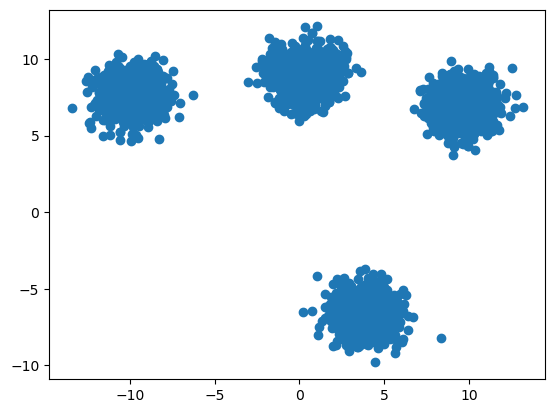

In [6]:
# plt.scatter(X[:,0], X[:,1])
plt.scatter(X[:, 0], X[:, 1])

In [11]:
from sklearn.model_selection import train_test_split
X_train, Y_train, X_test, Y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

In [12]:
from sklearn.cluster import KMeans

In [13]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

In [14]:
wcss

[307167.92429732607,
 129198.26695438218,
 52697.788608323375,
 10017.383661530648,
 9630.748483768748,
 9280.528091124168,
 8875.828634151145,
 8658.691654023212,
 8290.129219412334,
 8098.937678374949]

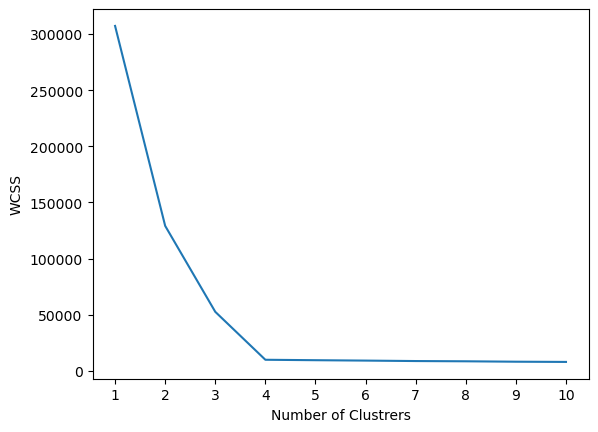

In [15]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [19]:
kmeans = KMeans(n_clusters=4, init='k-means++')

c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


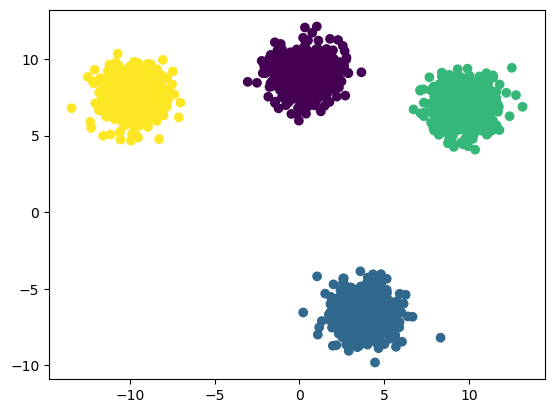

In [20]:
Y_labels = kmeans.fit_predict(X_train)
plt.scatter(X_train[:, 0], X_train[:, 1], c=Y_labels)

In [21]:
pip install kneed

In [23]:
# knee locater
from kneed import knee_locator

In [27]:
kl = knee_locator.KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
kl.elbow

4

In [30]:
# Performance metrics
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train)
    score=silhouette_score (X_train,kmeans.labels_)
    silhouette_coefficients.append(score)

c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of

In [31]:
silhouette_coefficients

[0.5674515623420496,
 0.7077272390341439,
 0.7986249692368674,
 0.6375304112339604,
 0.47861491636703163,
 0.30387340187755324,
 0.13970949205074443,
 0.14028779708455813,
 0.13854167535620937]